<a href="https://colab.research.google.com/github/jesusavilezmuneton21-ui/Prog_Civil_2026_1/blob/main/Prog_Trabajo_Aplicado_Func_Estructuras_Gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Aplicado: Funciones y Estructuras de Control

## Cálculo de Caudal en Canales Abiertos mediante la Ecuación de Manning

### Ecuación de Manning

$$
Q=\frac{1}{n} A R_h^{2/3} S^{1/2}
$$

Donde:

- $Q$ = Caudal ($m^3/s$)
- $n$ = Coeficiente de rugosidad de Manning
- $A$ = Área mojada ($m^2$)
- $R_h$ = Radio hidráulico ($m$)
- $S$ = Pendiente del canal

### Radio Hidráulico

$$
R_h=\frac{A}{P}
$$

donde:

- $A$ = Área mojada
- $P$ = Perímetro mojado

### Canal Rectangular

Área:

$$
A=b \cdot y
$$

Perímetro mojado:

$$
P=b+2y
$$

### Canal Trapezoidal

Área:

$$
A=(b+z\cdot y)\cdot y
$$

Perímetro mojado:

$$
P=b+2y\sqrt{1+z^2}
$$

Variables:

- $b$ = ancho de la base (m)
- $y$ = profundidad o tirante (m)
- $z$ = talud lateral

In [26]:
import math

def calcular_geometria(tipo_canal, b, y, z=0):
    """
    Calcula área mojada y perímetro mojado
    para canales rectangulares y trapezoidales.
    """

    if tipo_canal.lower() == "rectangular":
        A = b * y
        P = b + 2*y

    elif tipo_canal.lower() == "trapezoidal":
        A = (b + z*y) * y
        P = b + 2*y*(1 + z**2)

    else:
        raise ValueError("Tipo de canal no válido.")

    return A, P


# Prueba rápida
print(calcular_geometria("rectangular", 2, 1))

(2, 4)


In [27]:
def calcular_caudal(A, P, n, S):
    """
    Calcula el caudal usando la ecuación de Manning.
    """

    Rh = A / P

    Q = (1/n) * A * (Rh**(2/3)) * (S**0.5)

    return Q

In [28]:
# Parámetros fijos

b = 2.0       # ancho base (m)
z = 1.5       # talud lateral
n = 0.015     # rugosidad Manning
S = 0.001     # pendiente

tirantes = [0.5, 1.0, 1.5, 2.0]

print("RESULTADOS")
print("-"*65)
print(f"{'y(m)':<10}{'Q Rectangular':<20}{'Q Trapezoidal'}")
print("-"*65)

for y in tirantes:

    # Canal rectangular
    A_rect, P_rect = calcular_geometria(
        "rectangular",
        b,
        y
    )

    Q_rect = calcular_caudal(
        A_rect,
        P_rect,
        n,
        S
    )

    # Canal trapezoidal
    A_trap, P_trap = calcular_geometria(
        "trapezoidal",
        b,
        y,
        z
    )

    Q_trap = calcular_caudal(
        A_trap,
        P_trap,
        n,
        S
    )

    print(f"{y:<10.1f}{Q_rect:<20.3f}{Q_trap:.3f}")

RESULTADOS
-----------------------------------------------------------------
y(m)      Q Rectangular       Q Trapezoidal
-----------------------------------------------------------------
0.5       1.014               1.187
1.0       2.656               4.084
1.5       4.499               8.940
2.0       6.435               16.088


In [29]:
tirantes = [0.5, 1.0, 1.5, 2.0]

caudales_rect = []
caudales_trap = []

for y in tirantes:

    A_rect, P_rect = calcular_geometria(
        "rectangular",
        b,
        y
    )

    Q_rect = calcular_caudal(
        A_rect,
        P_rect,
        n,
        S
    )

    A_trap, P_trap = calcular_geometria(
        "trapezoidal",
        b,
        y,
        z

        )

    Q_trap = calcular_caudal(
        A_trap,
        P_trap,
        n,
        S
    )

    caudales_rect.append(Q_rect)
    caudales_trap.append(Q_trap)

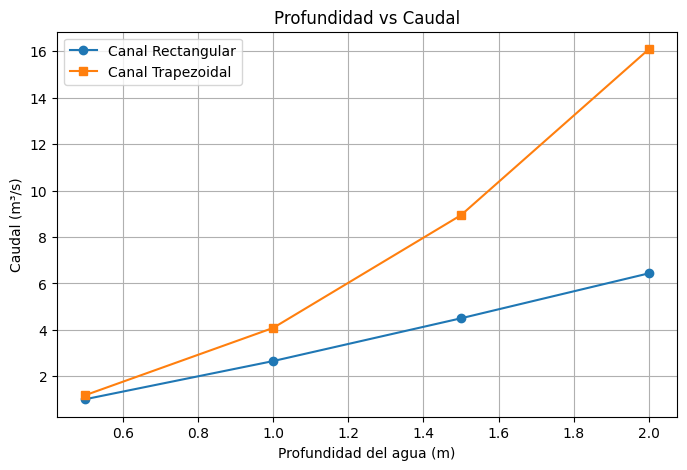

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    tirantes,
    caudales_rect,
    marker='o',
    label='Canal Rectangular'
)

plt.plot(
    tirantes,
    caudales_trap,
    marker='s',
    label='Canal Trapezoidal'
)

plt.title("Profundidad vs Caudal")
plt.xlabel("Profundidad del agua (m)")
plt.ylabel("Caudal (m³/s)")
plt.grid(True)
plt.legend()

plt.show()

## Análisis de Resultados

Se observa que el caudal aumenta al incrementarse la profundidad del flujo.

La curva correspondiente al canal trapezoidal crece más rápidamente que la del canal rectangular debido a que el área mojada aumenta no solamente en profundidad sino también lateralmente por efecto del talud.

Esto permite transportar mayores caudales para una misma profundidad, haciendo que los canales trapezoidales sean más eficientes hidráulicamente.